In [1]:
import cartopy.crs as ccrs
import xarray as xr
import pandas as pd
import numpy as np
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import pyplot as plt
import glob
import matplotlib
%matplotlib inline

In [2]:
#define focusing area
[min_lon_EA, max_lon_EA, min_lat_EA, max_lat_EA]=[100.,150.,12.,48.]
[min_lon_local, max_lon_local, min_lat_local, max_lat_local]=[114.,130.,18.,30.]
[min_lon_tw, max_lon_tw, min_lat_tw, max_lat_tw]=[118,126,22,26]
[min_lon_ish, max_lon_ish, min_lat_ish, max_lat_ish]=[122,126,22,26]

slp_levels=np.linspace(980,1040,16)
slp_lws=[2 if (pp-980)%20==0 else 1 for pp in slp_levels]

In [3]:
df=pd.read_csv('../data/cold_season_weather_regimes_with_idx.csv',header=0,parse_dates=[0])
#df=df[~df.date.isin(['%4d-02-29'%yr for yr in [2004,2008]])]
df.date.size

2122

In [4]:
dateList={}
for r,grp in df.groupby('regime'):
    print(r,grp.date.size)
    dateList[r]=grp.date.values

CS 48
FT 352
LCD 791
NE 782
TC 149


In [5]:
ds=xr.open_mfdataset(['../data/regridded_%04d.nc'%yr for yr in range(2005,2015)])
ds

<xarray.Dataset>
Dimensions:        (time: 3652, lat: 42, lon: 41)
Coordinates:
  * time           (time) datetime64[ns] 2005-01-01 2005-01-02 ... 2014-12-31
  * lat            (lat) float64 10.84 11.78 12.72 13.66 ... 47.59 48.53 49.48
  * lon            (lon) float64 100.0 101.2 102.5 103.8 ... 147.5 148.8 150.0
    level          float64 1e+03
Data variables:
    precipitation  (time, lat, lon) float32 dask.array<chunksize=(365, 42, 41), meta=np.ndarray>
    u              (time, lat, lon) float32 dask.array<chunksize=(365, 42, 41), meta=np.ndarray>
    v              (time, lat, lon) float32 dask.array<chunksize=(365, 42, 41), meta=np.ndarray>
    msl            (time, lat, lon) float32 dask.array<chunksize=(365, 42, 41), meta=np.ndarray>
    LTS            (time, lat, lon) float32 dask.array<chunksize=(365, 42, 41), meta=np.ndarray>
Attributes:
    DimensionNames:    time,lon,lat
    Units:             mm/hr
    units:             mm/hr
    CodeMissingValue:  -9999.9
    LongName:          \nComplete merged microwave-infrared (gauge-adjusted)\...
    regrid_method:     conservative

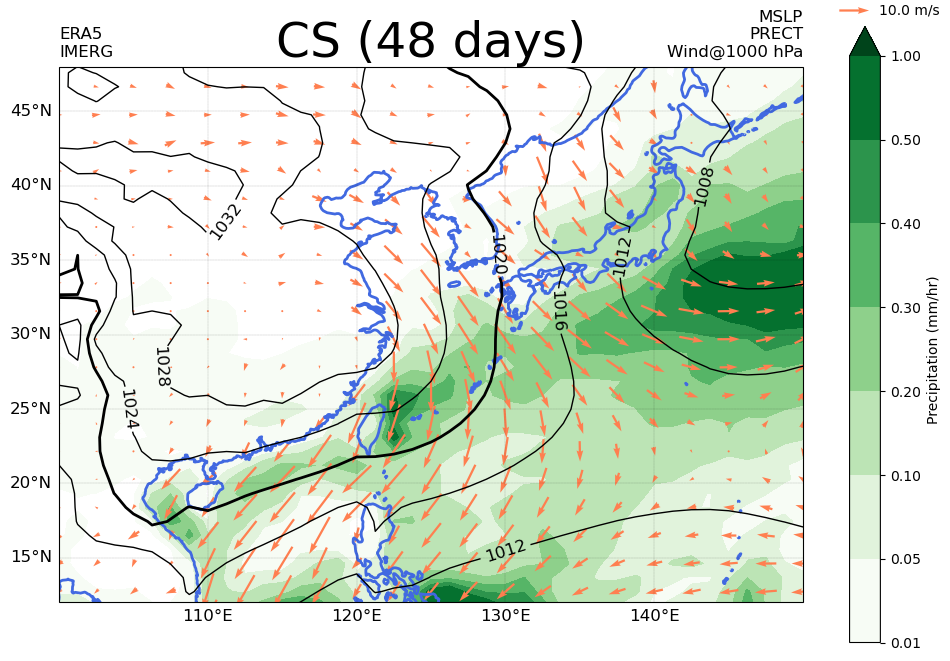

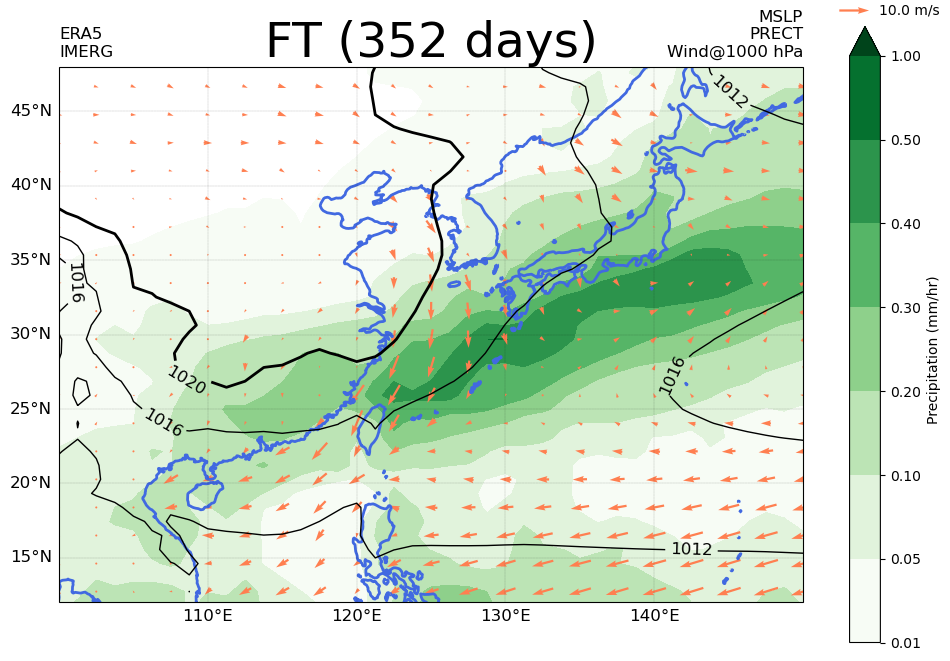

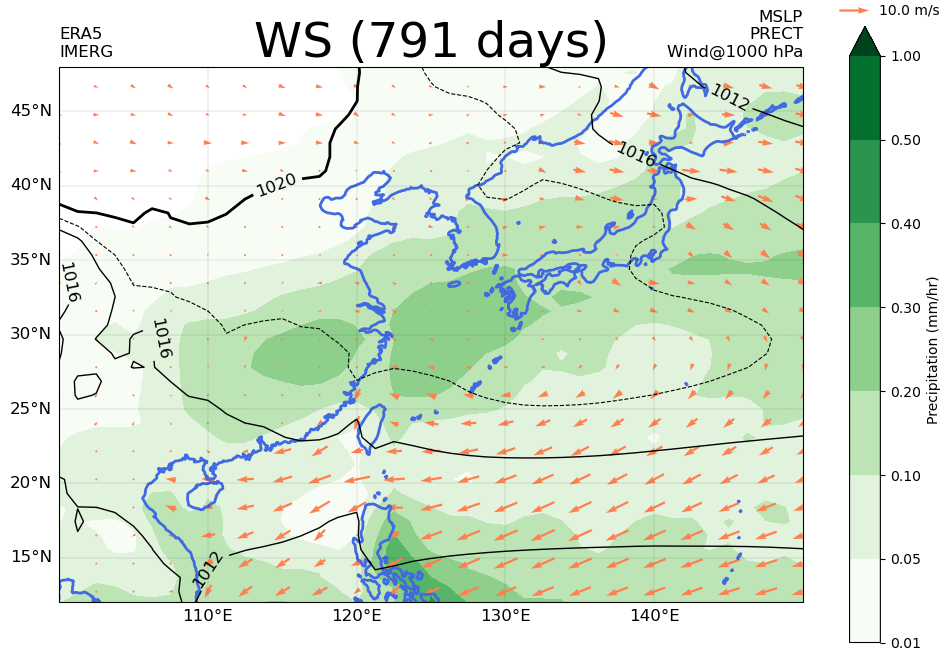

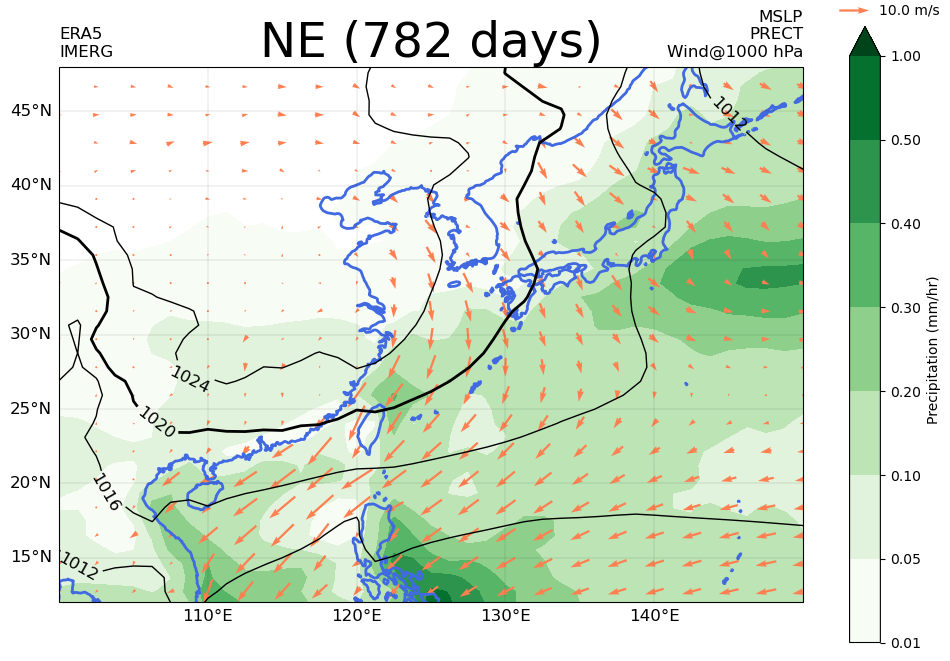

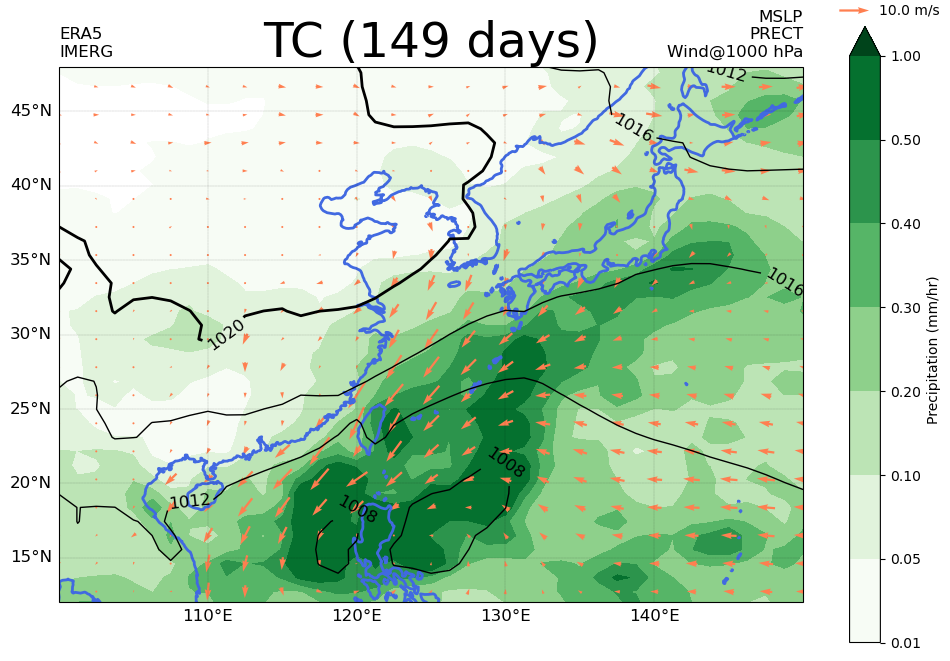

In [6]:
# plot East Asia weather map of each regime
for r in dateList.keys():
    ds_plot=ds.sel(time=dateList[r]).mean(dim='time')
    titleStr='%s (%d days)'%(r,dateList[r].shape[0])
    if r=='LCD':
        titleStr='%s (%d days)'%('WS',dateList[r].shape[0])
    resample = ds_plot.isel(lon=slice(None, None, 2),lat=slice(None, None, 2))
    # Defining the figure
    fig = plt.figure(figsize=(12,8), facecolor='w', edgecolor='k')

    # Axes with Cartopy projection
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    # and extent
    #ax.set_extent([min_lon_local, max_lon_local, min_lat_local, max_lat_local], ccrs.PlateCarree())
    ax.set_extent([min_lon_EA, max_lon_EA, min_lat_EA, max_lat_EA], ccrs.PlateCarree())

    # Plotting using Matplotlib the mean current
    cs_p = ds_plot['precipitation'].plot.contourf(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.2,0.3,0.4,0.5,1.0],\
                                                  extend='max',cmap='Greens',transform=ccrs.PlateCarree(),\
                                                  cbar_kwargs=dict(label='Precipitation (mm/hr)'))
    #cs_p2 = prect.plot.contour(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.5,1.0],cmap='hot_r',linewidths=1.2,transform=ccrs.PlateCarree())
    cs = ds_plot['msl'].plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=slp_levels,
                      colors='k',
                      linewidths=slp_lws)
    if r=='LCD':
        cs2 = ds_plot['msl'].plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=[1018,],
                      colors='k',  
                      linestyles=['--',],linewidths=[0.8,])
    q1=resample.plot.quiver(ax=ax,x='lon', y='lat', u='u', v='v', transform=ccrs.PlateCarree(),
                        scale=250,color='coral',width=0.003,add_guide=False)

    ax.clabel(cs, slp_levels, inline=True, fmt='%.0f', fontsize=12)
    #ax.clabel(cs_p2, [0.01,0.05,0.1,0.5,1.0], inline=True, fmt='%.2f', fontsize=12)
    #q1=ds_plot.plot.quiver(x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(), scale=80,color='g')
    ax.coastlines(resolution='50m',linewidth=2.0,color='royalblue')
    # Plot lat/lon grid 
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1, 
                  linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12} 

    #ax.plot([min_lon_tw, max_lon_tw,max_lon_tw,min_lon_tw,min_lon_tw],\
    #    [min_lat_tw,min_lat_tw, max_lat_tw,max_lat_tw,min_lat_tw],\
    #    lw=2.5,color='cyan',transform=ccrs.PlateCarree())
    #ax.plot([min_lon_ish, max_lon_ish,max_lon_ish,min_lon_ish,min_lon_ish],\
    #    [min_lat_ish,min_lat_ish, max_lat_ish,max_lat_ish,min_lat_ish],\
    #  lw=2.5,ls='--',color='r',transform=ccrs.PlateCarree())

    ax.set_title(titleStr,fontsize=35)
    ax.set_title('ERA5\nIMERG',fontsize=12,loc='left')
    ax.set_title('MSLP\nPRECT\nWind@1000 hPa',fontsize=12,loc='right')
    #ax.text(max_lon_tw+1,max_lat_tw-1.5,'prR=%.1f%%'%(prR*100),color='b',fontsize=15,transform=ccrs.PlateCarree())
    #ax.text(max_lon_tw+1,min_lat_tw+1,'WDCor=%.1f $\degree$'%wdCor,color='r',fontsize=15,transform=ccrs.PlateCarree())
    # Vector options declaration
    veclenght = 10
    maxstr = '%3.1f m/s' % veclenght
    plt.quiverkey(q1,0.8,0.9,veclenght,maxstr,labelpos='E', coordinates='figure').set_zorder(11)
    #plt.savefig('../figures/weatherMap_local.%s.ERA5.png'%r,dpi=200)
    plt.savefig('../figures/weatherMap.%s.ERA5.png'%r,dpi=200)

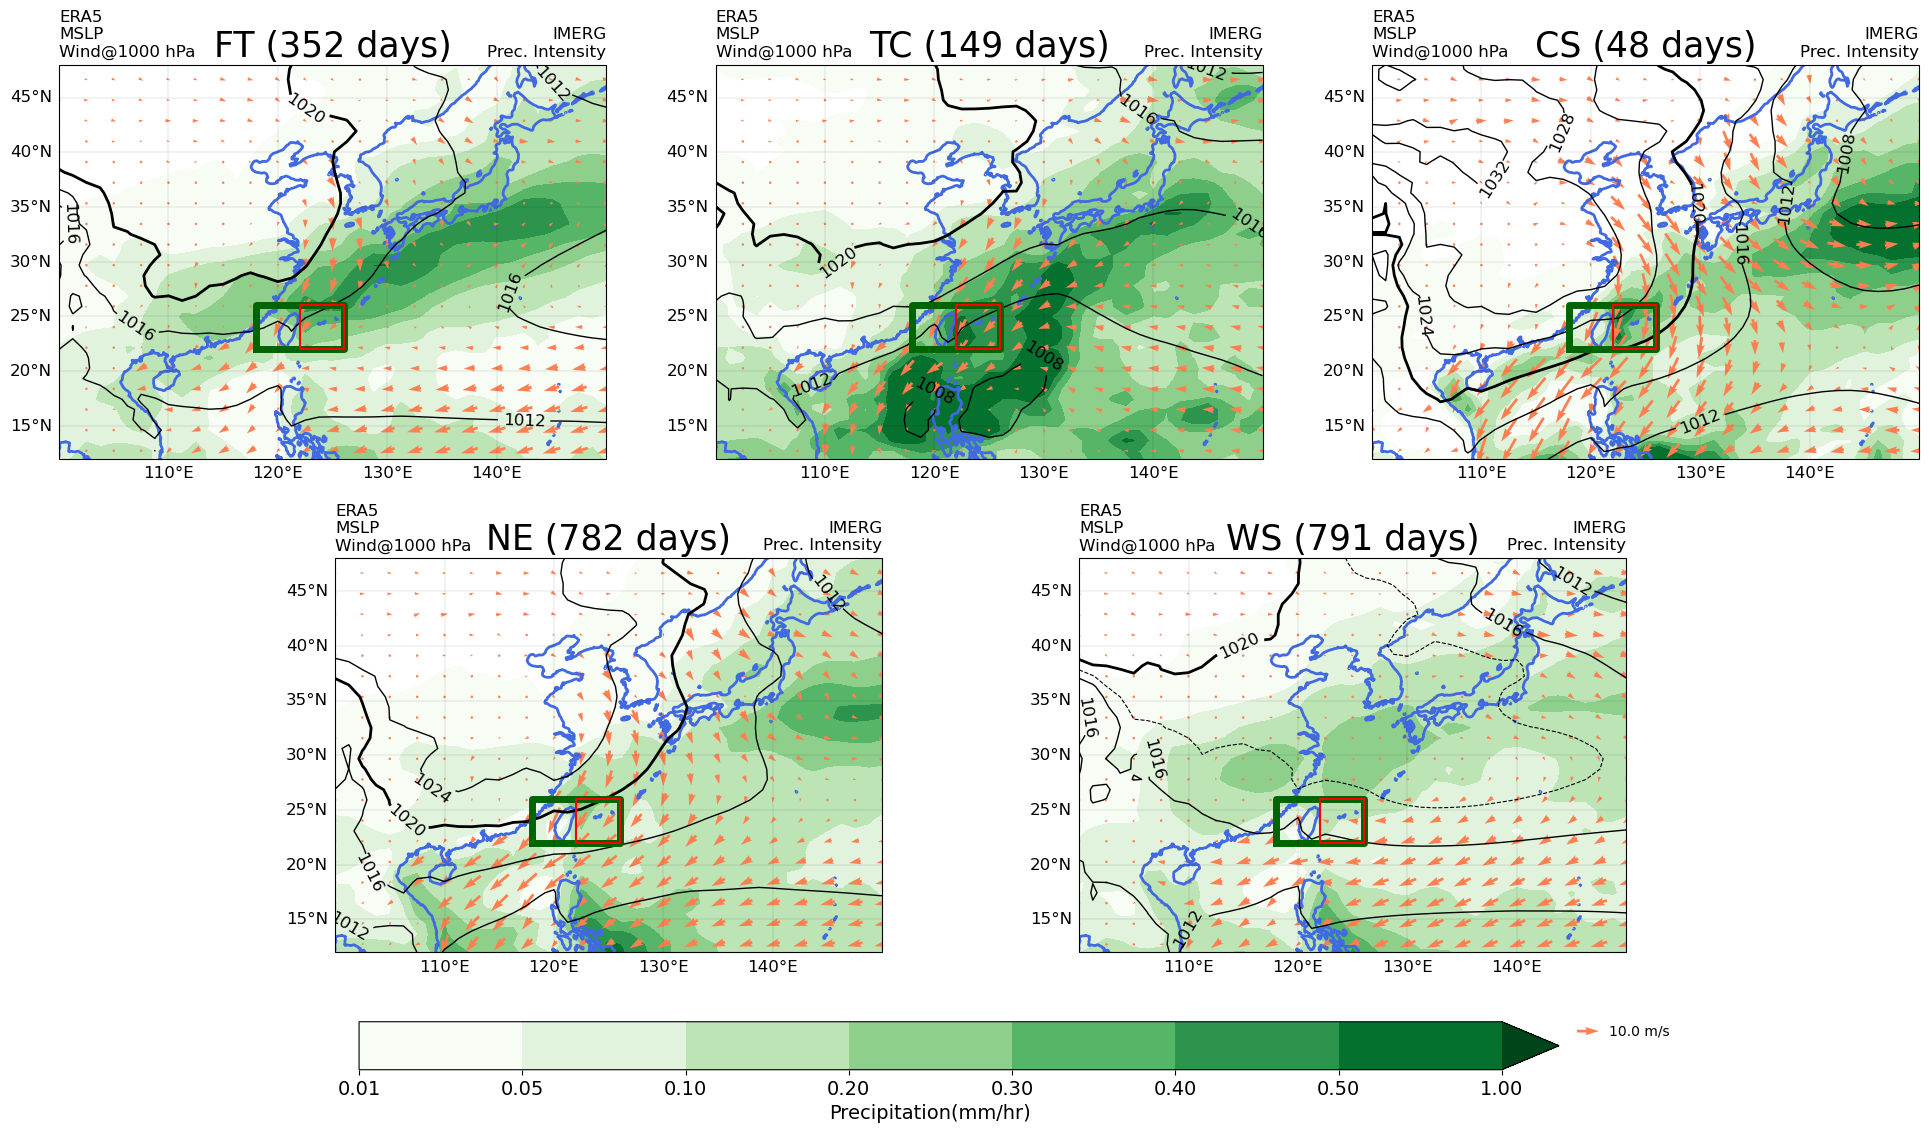

In [22]:
#put each regime in subplots
plt.close()
fig, axes = plt.subplots(2,3,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},figsize=(24,16),facecolor='w', edgecolor='k')
axes[1][2].set_visible(False)

# plot East Asia weather map of each regime
for ax,r in zip(axes.ravel()[:5],['FT','TC','CS','NE','LCD']):
    ds_plot=ds.sel(time=dateList[r]).mean(dim='time')
    titleStr='%s (%d days)'%(r,dateList[r].shape[0])
    if r=='LCD':
        titleStr='%s (%d days)'%('WS',dateList[r].shape[0])
    resample = ds_plot.isel(lon=slice(None, None, 2),lat=slice(None, None, 2))
    # Defining the figure
    # Axes with Cartopy projection
    #ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
    # and extent
    #ax.set_extent([min_lon_local, max_lon_local, min_lat_local, max_lat_local], ccrs.PlateCarree())
    ax.set_extent([min_lon_EA, max_lon_EA, min_lat_EA, max_lat_EA], ccrs.PlateCarree())

    # Plotting using Matplotlib the mean current
    cs_p = ds_plot['precipitation'].plot.contourf(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.2,0.3,0.4,0.5,1.0],\
                                                  extend='max',cmap='Greens',transform=ccrs.PlateCarree(),\
                                                  #cbar_kwargs=dict(label='Precipitation (mm/hr)'))
                                                  add_colorbar=False)
    #cs_p2 = prect.plot.contour(ax=ax,x='lon', y='lat',levels=[0.01,0.05,0.1,0.5,1.0],cmap='hot_r',linewidths=1.2,transform=ccrs.PlateCarree())
    cs = ds_plot['msl'].plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=slp_levels,
                      colors='k',
                      linewidths=slp_lws)
    if r=='LCD':
        cs2 = ds_plot['msl'].plot.contour(ax=ax,transform=ccrs.PlateCarree(),
                      levels=[1018,],
                      colors='k',  
                      linestyles=['--',],linewidths=[0.8,])
    q1=resample.plot.quiver(ax=ax,x='lon', y='lat', u='u', v='v', transform=ccrs.PlateCarree(),
                        scale=250,color='coral',width=0.005,add_guide=False)

    ax.clabel(cs, slp_levels, inline=True, fmt='%.0f', fontsize=12)
    #ax.clabel(cs_p2, [0.01,0.05,0.1,0.5,1.0], inline=True, fmt='%.2f', fontsize=12)
    #q1=ds_plot.plot.quiver(x='lon', y='lat', u='ua', v='va', transform=ccrs.PlateCarree(), scale=80,color='g')
    ax.coastlines(resolution='50m',linewidth=2.0,color='royalblue')
    # Plot lat/lon grid 
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1, 
                  linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12} 

    ax.plot([min_lon_tw, max_lon_tw,max_lon_tw,min_lon_tw,min_lon_tw],\
        [min_lat_tw,min_lat_tw, max_lat_tw,max_lat_tw,min_lat_tw],\
        lw=5,color='darkgreen',transform=ccrs.PlateCarree())
    ax.plot([min_lon_ish, max_lon_ish,max_lon_ish,min_lon_ish,min_lon_ish],\
        [min_lat_ish,min_lat_ish, max_lat_ish,max_lat_ish,min_lat_ish],\
      lw=1.5,color='r',transform=ccrs.PlateCarree())

    ax.set_title(titleStr,fontsize=25)
    ax.set_title('ERA5\nMSLP\nWind@1000 hPa',fontsize=12,loc='left')
    ax.set_title('IMERG\nPrec. Intensity',fontsize=12,loc='right')
    #ax.text(max_lon_tw+1,max_lat_tw-1.5,'prR=%.1f%%'%(prR*100),color='b',fontsize=15,transform=ccrs.PlateCarree())
    #ax.text(max_lon_tw+1,min_lat_tw+1,'WDCor=%.1f $\degree$'%wdCor,color='r',fontsize=15,transform=ccrs.PlateCarree())
    # Vector options declaration

    if r=='LCD':
        veclenght = 10
        maxstr = '%3.1f m/s' % veclenght
        ax.quiverkey(q1,0.95,-0.2,veclenght,maxstr,labelpos='E', linewidth=30,coordinates='axes')

axes[1][0].set_position([0.24,0.225,0.228,0.343])
axes[1][1].set_position([0.55,0.225,0.228,0.343])

#plt.tight_layout()

matplotlib.rc('xtick',labelsize=14)
cax=fig.add_axes([0.25, 0.2, 0.5, 0.03])
cbar=plt.colorbar(cs_p, cax=cax, orientation='horizontal',extend='max')
cbar.set_label('Precipitation(mm/hr)',fontsize=14)
plt.savefig('../figures/weatherMap_all_types.ERA5.png',bbox_inches='tight',dpi=200)
